In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('money.csv', sep=';', encoding='utf-8', skipinitialspace=True, decimal=',')
df1.columns = df1.columns.str.lower().str.replace(' ', '_')
print(df1.info())
print(df1.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB
None
       id  прибыль
0  215348     0.98
1  215349     4.16
2  215350     3.13
3  215351     4.87
4  215352     4.21


In [ ]:
df2 = pd.read_csv('market_time.csv', sep=',', encoding='utf-8', skipinitialspace=True)
df2.columns = df2.columns.str.lower().str.replace(' ', '_')
print(df2.info())
print(df2.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB
None
       id            период  минут
0  215348     текущий_месяц     14
1  215348  предыдцщий_месяц     13
2  215349     текущий_месяц     10
3  215349  предыдцщий_месяц     12
4  215350     текущий_месяц     13


Здесь видно, что сделана ошибка в слове в столбце период, так что нужно заменить слово 'предыдцщий' на 'предыдущий'

In [ ]:
df2['период'] = np.where((df2['период'] == 'предыдцщий_месяц'), 'предыдущий_месяц', df2['период'])
df2

,id,период,минут
0,215348,текущий_месяц,14
1,215348,предыдущий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдущий_месяц,12
4,215350,текущий_месяц,13
...,...,...,...
2595,216645,текущий_месяц,18
2596,216646,предыдущий_месяц,18
2597,216646,текущий_месяц,7
2598,216647,текущий_месяц,10


In [ ]:
df3 = pd.read_csv('market_money.csv', sep=',', encoding='utf-8', skipinitialspace=True)
df3.columns = df3.columns.str.lower().str.replace(' ', '_')
print(df3.info())
print(df3.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   период   3900 non-null   object 
 2   выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB
None
       id               период  выручка
0  215348  препредыдущий_месяц      0.0
1  215348        текущий_месяц   3293.1
2  215348     предыдущий_месяц      0.0
3  215349  препредыдущий_месяц   4472.0
4  215349        текущий_месяц   4971.6


In [ ]:
df4 = pd.read_csv('market_file.csv', sep=',', encoding='utf-8', skipinitialspace=True)
df4.columns = df4.columns.str.lower().str.replace(' ', '_')
print(df4.info())
print(df4.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   object 
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                

Здесь видно, что сделана ошибка в слове в столбце тип сервиса, так что нужно заменить слово 'стандартт' на 'стандарт'

In [ ]:
df4['тип_сервиса'] = np.where((df4['тип_сервиса'] == 'стандартт'), 'стандарт', df4['тип_сервиса'])
df4

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11
1296,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9
1297,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7
1298,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7


In [ ]:
df5 = pd.read_csv('forecast_chan.csv', sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
print(df5.info())
print(df5.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   вероятность  1297 non-null   float64
 1   id           1297 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 20.4 KB
None
   вероятность      id
0         1.00  215349
1         0.12  215350
2         0.97  215351
3         0.90  215352
4         1.00  215353


Шаг 1. Методом перебора я подобрала нужные кодировки, а также знаки разделения для каждого из файлов. Все колонки были переведены по стандарту pep8 в нижний регистр и добавлены нижние подчеркивания вместо пробелов. Некорретно написанные слова были заменены.

Все данные в таблицах соответствуют их описаниям в задаче

In [ ]:
df1.describe()

,id,прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


In [ ]:
df2.describe()

,id,минут
count,2600.000000,2600.000000
mean,215997.500000,13.336154
std,375.349754,4.080198
min,215348.000000,4.000000
25%,215672.750000,10.000000
50%,215997.500000,13.000000
75%,216322.250000,16.000000
max,216647.000000,23.000000


In [ ]:
df3.describe()

,id,выручка
count,3900.000000,3900.000000
mean,215997.500000,5025.696051
std,375.325686,1777.704104
min,215348.000000,0.000000
25%,215672.750000,4590.150000
50%,215997.500000,4957.500000
75%,216322.250000,5363.000000
max,216647.000000,106862.200000


Сразу заметно огромный выброс максимума в поле выручка - чересчур большая выручка за месяц. Пока что я не буду его удалять, возможно он один из тех самых активных покупателей и он поможет провести дальше анализ.

In [ ]:
df4.describe()

,id,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [ ]:
df5.describe()

,вероятность,id
count,1297.000000,1297.000000
mean,0.374449,215998.986893
std,0.387556,374.578554
min,0.000000,215349.000000
25%,0.120000,215675.000000
50%,0.120000,215999.000000
75%,0.900000,216323.000000
max,1.000000,216647.000000


Проверяем данные на пропуски

In [ ]:
print(df1.isna().sum())
print(df2.isna().sum())
print(df3.isna().sum())
print(df4.isna().sum())
print(df5.isna().sum())

id         0
прибыль    0
dtype: int64
id        0
период    0
минут     0
dtype: int64
id         0
период     0
выручка    0
dtype: int64
id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
dtype: int64
вероятность    0
id             0
dtype: int64


Убираем дубликаты

In [ ]:
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()
df3 = df3.drop_duplicates()
df4 = df4.drop_duplicates()
df5 = df5.drop_duplicates()

Шаг 2. Проведена предобработка данных (убраны дупликаты, обнаружено что пропусков не было, названия столбцов приведены к стандарту pep8, найдены выбросы в максимальной выручке за месяц, но решено их пока что оставить для дальнейшнего анализа)

Шаг 3. Проведем исследовательский анализ данных в каждой таблице

In [ ]:
print(df3.head())
print(df3['период'].unique())
#здесь уже 3 периода времени и выручка полученная магазином от каждого из покупателей
#можно посчитать клиентов у которых в каждом их трех месяцев выручка > 0 - значит у них была трехмесячная покупательская активность
money = df3.pivot(index='id', columns='период', values='выручка').reset_index()
money.columns = ['id', 'деньги_препредыдущий_месяц', 'деньги_предыдущий_месяц', 'деньги_текущий_месяц']
ids = money[(money['деньги_предыдущий_месяц'] > 0) & (money['деньги_текущий_месяц'] > 0) & (money['деньги_препредыдущий_месяц'] > 0)]['id'].to_list()

       id               период  выручка
0  215348  препредыдущий_месяц      0.0
1  215348        текущий_месяц   3293.1
2  215348     предыдущий_месяц      0.0
3  215349  препредыдущий_месяц   4472.0
4  215349        текущий_месяц   4971.6
['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


1297

In [ ]:
df1.head()
#данная таблица просто показывает данные о среднемесячной прибыли покупателя
#за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю
#но она не показывает сколько потратил покупатель в каждый из месяцев

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [ ]:
print(df2.head())
#данная таблица показывает сколько минут человек провел на сайте за определенный период времени
print(df2['период'].unique())
#но здесь только 2 периода, значит эта таблица нам не подойдет

       id            период  минут
0  215348     текущий_месяц     14
1  215348  предыдущий_месяц     13
2  215349     текущий_месяц     10
3  215349  предыдущий_месяц     12
4  215350     текущий_месяц     13
['текущий_месяц' 'предыдущий_месяц']


In [ ]:
df5.head()
#данная таблица показывает готовую вероятность снижения активности покупателя

,вероятность,id
0,1.00,215349
1,0.12,215350
2,0.97,215351
3,0.90,215352
4,1.00,215353


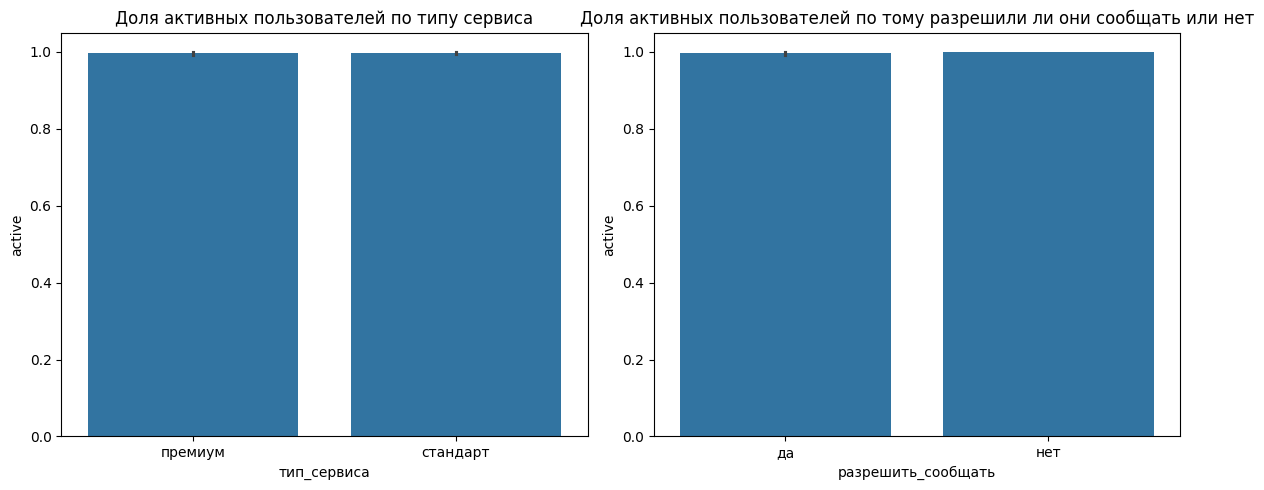

1.0
0.7121466018122491


In [ ]:
#данная таблица показывает покупательскую активность и многие другие факторы
#попробую провести анализ зависимости покупательской активности/типа сервиса/разрашения на сообщение предложений на то активный ли пользователь в течение 3 месяцев или нет
#надо добавить колонку с тем активный ли покупатель или нет
df4['active'] = [1 if x in ids else 0 for x in df4['id']]
#можно понаблюдать долю активных пользователей в каждой из групп
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='тип_сервиса', y='active', data=df4, ax=axes[0])
axes[0].set_title('Доля активных пользователей по типу сервиса')
sns.barplot(x='разрешить_сообщать', y='active', data=df4, ax=axes[1])
axes[1].set_title('Доля активных пользователей по тому разрешили ли они сообщать или нет')
plt.tight_layout()
plt.show()
#пока что то показывает незначительность этих признаков в активности во все 3 месяца
table = pd.crosstab(df4['тип_сервиса'], df4['active'])
p1 = st.chi2_contingency(table)[1]
print(p1)
table = pd.crosstab(df4['разрешить_сообщать'], df4['active'])
p2 = st.chi2_contingency(table)[1]
print(p2)
#в обоих случаях p в разы больше 0.05, так что данные признаки совсем незначительны в определении пользовательской активности во все 3 месяца

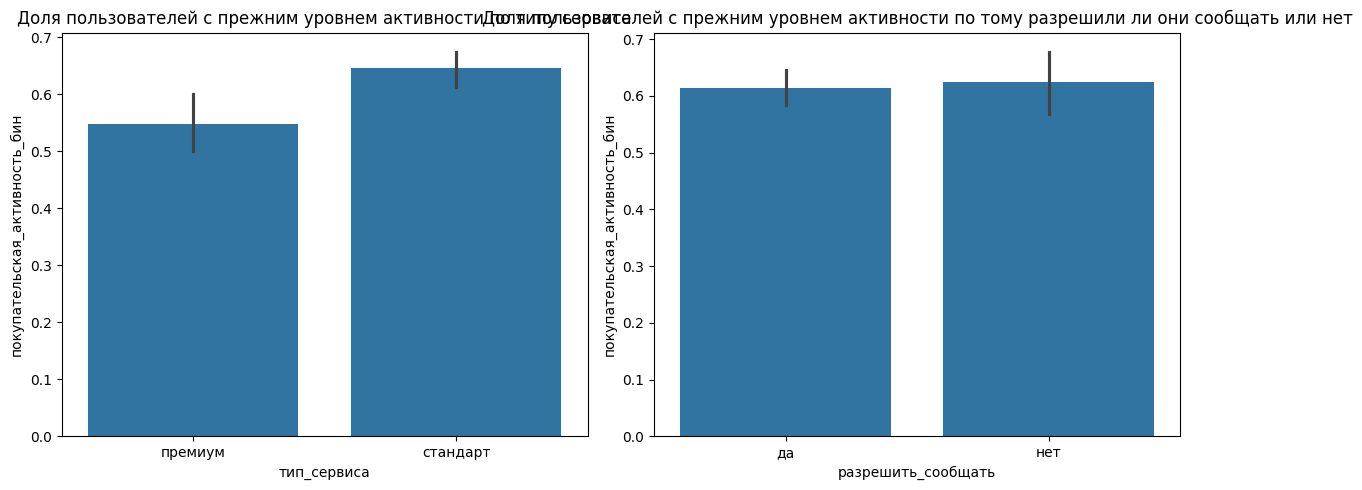

0.0013552678292615076
0.7967675314637721


In [ ]:
#теперь попробуем сделать тоже самое но уже сравнивая со столбцом пользовательская активность
#для этого для начала надо преобразовать его в бинарный вид
df4['покупательская_активность_бин'] = np.where(df4['покупательская_активность'] == 'Прежний уровень', 1, 0)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='тип_сервиса', y='покупательская_активность_бин', data=df4, ax=axes[0])
axes[0].set_title('Доля пользователей с прежним уровнем активности по типу сервиса')
sns.barplot(x='разрешить_сообщать', y='покупательская_активность_бин', data=df4, ax=axes[1])
axes[1].set_title('Доля пользователей с прежним уровнем активности по тому разрешили ли они сообщать или нет')
plt.tight_layout()
plt.show()
#пока что график показывает незначительность разрешения на сообщение на пользовательскую активность, но довольно высокое класса стандарт
table = pd.crosstab(df4['тип_сервиса'], df4['покупательская_активность_бин'])
p1 = st.chi2_contingency(table)[1]
print(p1)
table = pd.crosstab(df4['разрешить_сообщать'], df4['покупательская_активность_бин'])
p2 = st.chi2_contingency(table)[1]
print(p2)
#в первом случае p < 0.05, что показывает статистически значимую связь между типом сервиса и тем, что уровень активности пользователя не снизился
#во втором же случае значимой связи не обнаружено

Шаг 4. Провести EDA по таблицам market_file.csv, market_money.csv, market_time.csv, объединив их в одну

In [ ]:
print(df2)
time = df2.pivot(index='id', columns='период', values='минут').reset_index()
time.columns = ['id', 'время_предыдущий_месяц', 'время_текущий_месяц']
df_merged = df4.merge(money, on='id', how='left')
df_merged = df_merged.merge(time, on='id', how='left')
df_merged_active = df_merged[df_merged['id'].isin(ids)].copy()
df_merged_active
#создание общей таблицы из трех (market_file.csv, market_money.csv, market_time.csv. )

          id            период  минут
0     215348     текущий_месяц     14
1     215348  предыдущий_месяц     13
2     215349     текущий_месяц     10
3     215349  предыдущий_месяц     12
4     215350     текущий_месяц     13
...      ...               ...    ...
2595  216645     текущий_месяц     18
2596  216646  предыдущий_месяц     18
2597  216646     текущий_месяц      7
2598  216647     текущий_месяц     10
2599  216647  предыдущий_месяц     15

[2600 rows x 3 columns]


,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,active,покупательская_активность_бин,деньги_препредыдущий_месяц,деньги_предыдущий_месяц,деньги_текущий_месяц,время_предыдущий_месяц,время_текущий_месяц
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,1,0,5216.0,4472.0,4971.6,12,10
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,1,0,5457.5,4826.0,5058.4,8,13
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,1,0,6158.0,4793.0,6610.4,11,13
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,1,0,5807.5,4594.0,5872.5,8,11
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,1,0,4738.5,5124.0,5388.5,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,1,1,3664.0,4704.0,4741.7,14,7
1296,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,1,1,4729.0,5299.0,5353.0,12,11
1297,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,1,1,5160.0,5334.0,5139.2,12,18
1298,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,1,1,4923.0,4725.0,5224.6,18,7


Шаг 5. Корреляционный анализ
Проведите корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования.

In [ ]:
numeric_columns = df_merged_active.select_dtypes(include=[np.number]).columns.to_list()
numeric_columns.remove('id')
numeric_columns.remove('active')
print(numeric_columns)
corr_m = df_merged_active[numeric_columns].corr()
corr_m
#корреляционная связь количественных данных друг с другом
#также можно реализовать тепловую карту для подробного изучения

['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'покупательская_активность_бин', 'деньги_препредыдущий_месяц', 'деньги_предыдущий_месяц', 'деньги_текущий_месяц', 'время_предыдущий_месяц', 'время_текущий_месяц']


,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,покупательская_активность_бин,деньги_препредыдущий_месяц,деньги_предыдущий_месяц,деньги_текущий_месяц,время_предыдущий_месяц,время_текущий_месяц
маркет_актив_6_мес,1.000000,0.058556,-0.039157,-0.242752,0.203090,-0.164073,0.034421,0.314881,0.395745,0.016442,0.241783,-0.063322,0.288170,0.221858
маркет_актив_тек_мес,0.058556,1.000000,-0.134009,-0.005580,-0.023904,0.054997,0.087952,0.005229,0.003604,-0.033834,-0.042649,-0.005080,0.011086,-0.066598
длительность,-0.039157,-0.134009,1.000000,0.012158,-0.054612,-0.092609,0.112254,-0.039542,-0.062687,0.010120,-0.050222,0.008177,-0.122151,0.092506
акционные_покупки,-0.242752,-0.005580,0.012158,1.000000,-0.170592,0.190992,-0.024746,-0.307003,-0.419158,-0.001828,-0.200848,0.070330,-0.271253,-0.217316
средний_просмотр_категорий_за_визит,0.203090,-0.023904,-0.054612,-0.170592,1.000000,-0.274460,0.007024,0.240079,0.374402,-0.039673,0.140738,-0.026270,0.135454,0.225631
неоплаченные_продукты_штук_квартал,-0.164073,0.054997,-0.092609,0.190992,-0.274460,1.000000,-0.092196,-0.194615,-0.353695,-0.005893,-0.262823,-0.000524,-0.182694,-0.206926
ошибка_сервиса,0.034421,0.087952,0.112254,-0.024746,0.007024,-0.092196,1.000000,0.087651,0.098646,0.039707,0.076182,0.006466,0.187261,0.074364
страниц_за_визит,0.314881,0.005229,-0.039542,-0.307003,0.240079,-0.194615,0.087651,1.000000,0.515540,-0.040131,0.292719,-0.016243,0.425325,0.254452
покупательская_активность_бин,0.395745,0.003604,-0.062687,-0.419158,0.374402,-0.353695,0.098646,0.515540,1.000000,-0.028656,0.370841,-0.051387,0.504768,0.420453
деньги_препредыдущий_месяц,0.016442,-0.033834,0.010120,-0.001828,-0.039673,-0.005893,0.039707,-0.040131,-0.028656,1.000000,0.328247,0.280486,-0.065080,-0.052204


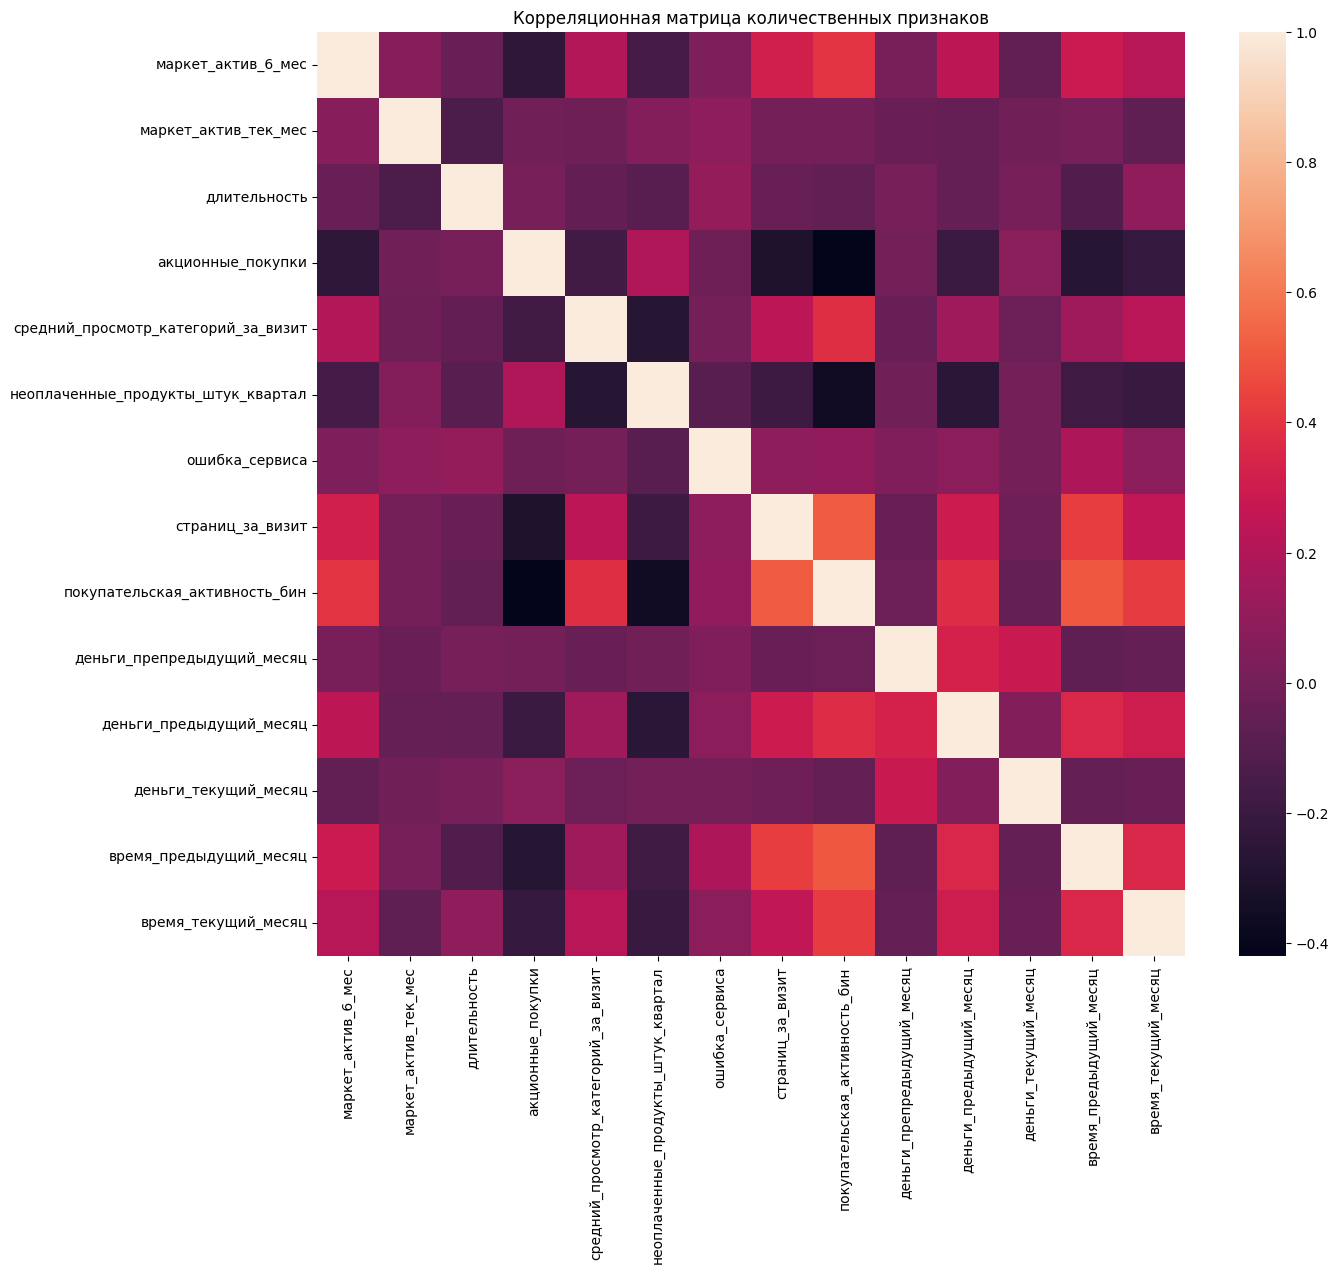

In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_m)
plt.title('Корреляционная матрица количественных признаков')
plt.show()

Из карты выше можно выделить пару сильных корреляций:
1. Cреднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев сильно коррелировано с его покупательской активностью
2. Также можно выделить корреляцию количества страниц за визит, среднего просмотра категорий за визит и покупательской активности клиента, что логично
3. Видна корреляция покупательской активности и времени проведенным клиентом на сайте в предыдущем и текущем месяце
4. Выручка предыдущего месяца сильно коррелирует с выручкой препредыдущего, что говорит о стабильности покупательского поведения
5. Акционные покупки и количество неоплаченных товаров в корзине за последние 3 месяца сильно отрицательно коррелируют с покупательской активностью

Все признаки сильно коррелирующие с покупательской активностью с большей вероятностью и будут являться критериями постоянных клиентов

Шаг 6.1 Мне нужно произвести сегментацию покупателей исходя из выводов выше и отобрать самых активных и постоянных клиентов.

Я хочу выделить таких клиентов:
1. C прежним уровнем пользовательской активности
2. У которых среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев выше 0.5 квантиля
3. У которых количество страниц за визит и средний просмотр категорий за визит выше 0.5 квантиля
4. У которых время, проведенное на сайте в предыдущем и текущем месяце выше 0.5 квантиля
5. У которых акционные покупки за 3 месяца ниже 0.5 квантиля
6. У которых сумма выручки за 3 месяца больше 0.5 квантиля

In [ ]:
df_merged_active['сумма_выручки'] = df_merged_active.loc[:, ['деньги_препредыдущий_месяц', 'деньги_предыдущий_месяц', 'деньги_текущий_месяц']].sum(axis=1)

In [ ]:
segment = df_merged_active[(df_merged_active['покупательская_активность_бин'] == 1)
 & (df_merged_active['средний_просмотр_категорий_за_визит'] > df_merged_active['средний_просмотр_категорий_за_визит'].quantile(0.5))
 & (df_merged_active['страниц_за_визит'] > df_merged_active['страниц_за_визит'].quantile(0.5))
 & (df_merged_active['акционные_покупки'] < df_merged_active['акционные_покупки'].quantile(0.6))
 & (df_merged_active['маркет_актив_6_мес'] > df_merged_active['маркет_актив_6_мес'].quantile(0.5))
 & (df_merged_active['время_предыдущий_месяц'] > df_merged_active['время_предыдущий_месяц'].quantile(0.5))
& (df_merged_active['время_текущий_месяц'] > df_merged_active['время_текущий_месяц'].quantile(0.5))
& (df_merged_active['сумма_выручки'] > df_merged_active['сумма_выручки'].quantile(0.4))]

In [ ]:
print(segment.head())
print(segment.columns.unique())
segment

         id покупательская_активность тип_сервиса разрешить_сообщать  \
422  215770           Прежний уровень    стандарт                 да   
430  215778           Прежний уровень    стандарт                 да   
431  215779           Прежний уровень     премиум                 да   
437  215785           Прежний уровень     премиум                 да   
521  215869           Прежний уровень    стандарт                 да   

     маркет_актив_6_мес  маркет_актив_тек_мес  длительность  \
422                 5.4                     5           749   
430                 4.3                     4           609   
431                 4.3                     3           242   
437                 4.9                     4           899   
521                 5.4                     4           559   

     акционные_покупки            популярная_категория  \
422               0.14                Товары для детей   
430               0.24                Товары для детей   
431           

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,...,страниц_за_визит,active,покупательская_активность_бин,деньги_препредыдущий_месяц,деньги_предыдущий_месяц,деньги_текущий_месяц,время_предыдущий_месяц,время_текущий_месяц,сумма_выручки,сумма_времени
422,215770,Прежний уровень,стандарт,да,5.4,5,749,0.14,Товары для детей,5,...,9,1,1,5298.0,5175.0,5321.4,20,14,15794.4,34
430,215778,Прежний уровень,стандарт,да,4.3,4,609,0.24,Товары для детей,4,...,15,1,1,4911.0,5364.0,5433.6,20,19,15708.6,39
431,215779,Прежний уровень,премиум,да,4.3,3,242,0.16,Техника для красоты и здоровья,4,...,11,1,1,5949.0,5142.0,5379.6,19,15,16470.6,34
437,215785,Прежний уровень,премиум,да,4.9,4,899,0.24,Домашний текстиль,4,...,17,1,1,5294.0,5045.0,5639.8,17,16,15978.8,33
521,215869,Прежний уровень,стандарт,да,5.4,4,559,0.17,Домашний текстиль,5,...,12,1,1,4965.5,4370.0,5611.6,16,19,14947.1,35
641,215989,Прежний уровень,стандарт,да,4.7,4,529,0.24,Мелкая бытовая техника и электроника,4,...,11,1,1,6159.5,4982.0,7310.0,20,20,18451.5,40
700,216048,Прежний уровень,стандарт,да,5.2,5,153,0.14,Техника для красоты и здоровья,6,...,9,1,1,5544.0,5574.0,5700.0,15,20,16818.0,35
801,216149,Прежний уровень,стандарт,да,5.7,4,290,0.16,Мелкая бытовая техника и электроника,5,...,12,1,1,5354.0,4820.0,5946.8,19,17,16120.8,36
820,216168,Прежний уровень,стандарт,да,5.5,4,577,0.17,Товары для детей,4,...,16,1,1,5551.0,4707.0,4949.1,22,16,15207.1,38
839,216187,Прежний уровень,премиум,нет,5.9,4,894,0.20,Товары для детей,4,...,14,1,1,4952.0,5241.0,5332.9,14,18,15525.9,32


Шаг 6.2 Нужно провести аналитический и графический анализ активных и постоянных клиентов

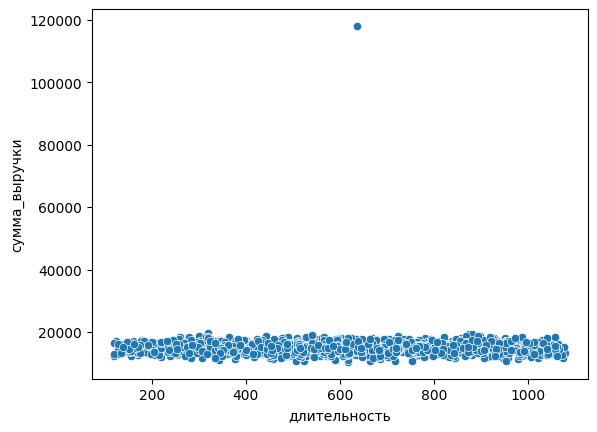

In [ ]:
#попробуем найти зависимости между длительностью с момента регистрации на сайте и выручкой
sns.scatterplot(x='длительность', y='сумма_выручки', data=df_merged_active)
plt.show()

Из графика выше можно понять что выручка от длительности вообще не зависит, но при этом есть один выброс который этому соответствует

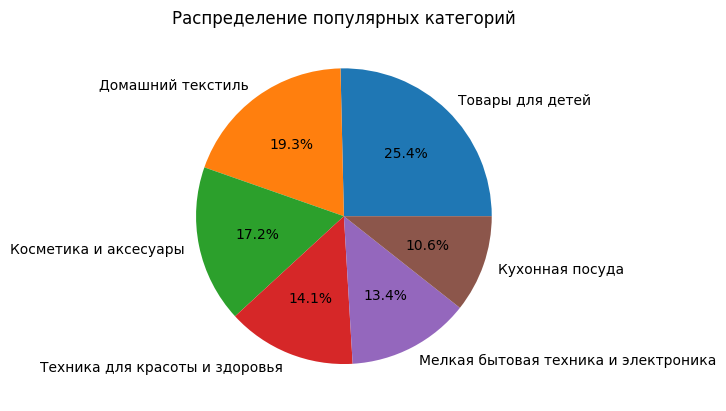

In [ ]:
#можно попробовать выявить распределение категорий у постоянных клиентов, чтобы понять что они чаще всего покупают
counts = df_merged_active['популярная_категория'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Распределение популярных категорий')
plt.show()

Надо запомнить самые популярные категории и попробовать давать скидки/купоны на них в будущем постоянным клиентам

In [ ]:
#также можно попробовать найти зависимость между типом сервиса и суммой выручки аналитически
g1 = df_merged_active[df_merged_active['разрешить_сообщать'] == 'да']['сумма_выручки']
g2 = df_merged_active[df_merged_active['разрешить_сообщать'] == 'нет']['сумма_выручки']
if st.shapiro(g1)[1] > 0.05 and st.shapiro(g2)[1] > 0.05:
  p = st.ttest_ind(g1, g2)[1]
else:
  p = st.mannwhitneyu(g1, g2)[1]
print(p)

0.9022161397810778


Так как p-value очень высокое, это указание на то, что разрешение на сообщения не влияет на суммарную выручку в ваших данных

In [ ]:
df_merged_active['сумма_времени'] = df_merged_active.loc[:, ['время_предыдущий_месяц', 'время_текущий_месяц']].sum(axis=1)

In [ ]:
#рассмотрим зависимость суммарного времени от суммарной выручки клиентов
if st.shapiro(df_merged_active['сумма_времени'])[1] > 0.05 and st.shapiro(df_merged_active['сумма_выручки'])[1] > 0.05:
  print(st.pearsonr(df_merged_active['сумма_времени'], df_merged_active['сумма_выручки'])[1])
else:
  print(st.spearmanr((df_merged_active['сумма_времени']), df_merged_active['сумма_выручки'])[1])

0.040293600829964284


Так как p-value меньше 0.05 - данные факторы имеют значимую корреляцию

Шаг 6.3 Целевой сегмент сформирован из постоянных клиентов – тех, кто совершал покупки во всех трёх анализируемых месяцах.
Дополнительно к этому сегмент отобран по совокупности признаков:
1. Высокая суммарная выручка за три месяца
2. Высокий средний просмотр категорий за визит
3. Высокое количество страниц за визит
4. Высокое время на сайте (за текущий и предыдущий месяц)
5. Низкая доля акционных покупок
6. Высокая маркетная активность за 6 месяцев
7. У которых покупательская активность осталась прежней

Шаг 6.3 Предложения

1. Поскольку выявлена положительная корреляция между маркетинговой активностью за последние 6 месяцев и покупательской активностью важно поддерживать их маркетинговый интерес не навязываясь

2. Предлагать персонализированные рассылки с рекомендациями товаров, основанными на истории просмотров и покупок, делать рекомендации по популярным товарам

3. Развивать программы лояльности с накопительной системой бонусов с возможностью обмена на товары, услуги или подарки

4. Учитывая, что лояльные пользователи активно просматривают категории и страницы, можно углубить их вовлечённость через качественный контент или улучшение дизайна и содержания сайта

5. Так как акционные покупки отрицательно коррелируют с активностью, можно сделать акцент на эксклюзивных условиях, а не на снижении цены и акциях

6. Суммарное время за последние месяцы сильно коррелирует с суммарной выручкой, так что надо научиться завлекать клиента неотталкивающими и ненавязывающимися простыми играми/вращением колес с получением бонусов/предложений. Так клиент будет больше времени проводить на сайте -> приносить больше выручки с большей вероятностью

Шаг 7.
Проведён исследовательский анализ данных о покупательской активности, выручке и поведении клиентов
После объединения таблиц, очистки и предобработки данных отобраны клиенты с покупками во всех трёх месяцах.
Корреляционный анализ показал, что покупательская активность положительно связана с маркетинговыми коммуникациями, временем на сайте, количеством страниц за визит и суммой выручки и отрицательно – с долей акционных покупок и количеством невыкупленных продуктов за 3 месяца.
На основе этой информации был выделен наиболее ценный сегмент состоящий из 33 клиентов (2.5%).
Для повышения активности предложены персонализированные рекомендации, программа лояльности с бонусами, геймификация.
Исполнение этих мер позволит увеличить и укрепить лояльность клиентов